In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# =========================================================
# GLOBAL CONFIGURATION (rcParams)
# =========================================================

# 1. FONT AND TEXT SETTINGS
# ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato', 'DejaVu Sans'],  # Priority list of clean fonts
    'font.size': 11,                                                   # Base font size for all elements

    # Specific settings for titles and axes
    'axes.titlesize': 15,                                              # Larger plot title size
    'axes.titleweight': 'bold',                                        # Bold title for emphasis
    'axes.labelsize': 13,                                              # Axis labels size (larger than base)
    'legend.fontsize': 11,                                             # Legend text size
})


# 2. AXES, TICKS, AND GRID SETTINGS
# ---
plt.rcParams.update({
    # GRID: Light and non-intrusive
    'axes.grid': True,              # Enable grid by default
    'grid.linestyle': '--',         # Dashed grid lines
    'grid.color': 'lightgray',      # Light color for grid
    'grid.alpha': 0.7,              # Transparency for grid

    # AXES SPINES (The box outline)
    'axes.spines.right': True,      # Draw right spine
    'axes.spines.top': True,        # Draw top spine
    'axes.edgecolor': 'black',      # Black color for the box outline
    'axes.linewidth': 1.2,          # Thickness of the box outline

    # MAJOR TICKS (The main markings with numbers)
    'xtick.direction': 'in',        # Major ticks pointing inwards
    'ytick.direction': 'in',
    'xtick.major.size': 6,          # Major tick length
    'ytick.major.size': 6,
    'xtick.top': True,              # Draw major ticks on the top side
    'ytick.right': True,            # Draw major ticks on the right side
    'xtick.labeltop': True,         # Show numbers on the upper X axis
    'ytick.labelright': True,       # Show numbers on the right Y axis
    
    # MINOR TICKS (Small markings between major ticks)
    'xtick.minor.visible': True,    # Enable minor ticks
    'ytick.minor.visible': True,
    'xtick.minor.top': True,        # Draw minor ticks on the top side
    'ytick.minor.right': True,
    'xtick.minor.size': 4,          # Minor tick length
    'xtick.minor.width': 0.8,       # Minor tick thickness
    'ytick.minor.width': 0.8,
})


# 3. LINES AND MARKERS SETTINGS
# ---
plt.rcParams.update({
    'lines.linewidth': 2.0,         # Default thickness for primary plot lines
    'lines.markersize': 4,          # Default size for data markers
    'lines.markeredgewidth': 1.0,   # Controls marker border thickness AND errorbar caps
})


# 4. ERRORBAR SETTINGS
# ---
plt.rcParams.update({
    'errorbar.capsize': 0.0,        # Length of the horizontal "caps" at the ends
})


# 5. LEGEND AND SAVING SETTINGS
# ---
plt.rcParams.update({
    # High-quality export settings (Best for a thesis)
    'figure.dpi': 300,              # Default display resolution (high quality)
    'savefig.format': 'png',        # Default save format to PNG (Vector format)
    'savefig.bbox': 'tight',        # Automatically trim excess white space
    'savefig.pad_inches': 0.05,     # Small padding to prevent clipping

    # Legend Appearance
    'legend.frameon': True,         # Draw a box around the legend
    'legend.edgecolor': 'lightgray',# Light border for the legend box
    'legend.fancybox': True,        # Slightly rounded legend border
})

In [ ]:
pos1 = np.loadtxt("equilibration/scenario1/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos2 = np.loadtxt("equilibration/scenario2/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos3 = np.loadtxt("equilibration/scenario3/OUTPUT/walker.dat", usecols=(0), unpack=True)

step, acceptance1 = np.loadtxt("equilibration/scenario1/OUTPUT/acceptance.dat", usecols=(0,1), unpack=True)
acceptance2 = np.loadtxt("equilibration/scenario2/OUTPUT/acceptance.dat", usecols=(1))
acceptance3 = np.loadtxt("equilibration/scenario3/OUTPUT/acceptance.dat", usecols=(1))
h1 = np.loadtxt("equilibration/scenario1/OUTPUT/hamiltonian.dat", usecols=(1))
h2 = np.loadtxt("equilibration/scenario2/OUTPUT/hamiltonian.dat", usecols=(1))
h3 = np.loadtxt("equilibration/scenario3/OUTPUT/hamiltonian.dat", usecols=(1))
print(len(step))

xmin = min(step) - 100
xmax = max(step) + 100
acf_step = len(step)

import re

def leggi_nparam_da_input(nome_file):
    """
    Legge un file, cerca la riga che inizia con 'NPARAM' e salva 
    il secondo e il terzo dato (valore2 e valore3) in variabili separate.

    Args:
        nome_file (str): Il percorso del file da leggere.

    Returns:
        tuple: (valore2, valore3) se la riga viene trovata, altrimenti (None, None).
    """
    # 1. Pattern per trovare la riga NPARAM e catturare i tre valori successivi
    # ^\s*NPARAM\s+  -> Inizia la riga (^), con spazi opzionali (\s*) seguiti da NPARAM e uno o più spazi (\s+)
    # (\S+)          -> Gruppo 1: Cattura il primo valore non-spazio (valore1)
    # \s+            -> Uno o più spazi
    # (\S+)          -> Gruppo 2: Cattura il secondo valore non-spazio (valore2)
    # \s+            -> Uno o più spazi
    # (\S+)          -> Gruppo 3: Cattura il terzo valore non-spazio (valore3)
    pattern = re.compile(r"^\s*NPARAM\s+\S+\s+(\S+)\s+(\S+)") 

    try:
        with open(nome_file, 'r') as file:
            for riga in file:
                # Cerca la riga corrispondente al pattern
                match = pattern.search(riga)
                
                if match:
                    # Trovata la riga!
                    # match.group(1) è il secondo valore catturato (valore2)
                    # match.group(2) è il terzo valore catturato (valore3)
                    
                    # Tentiamo di convertire i valori in float o intero
                    try:
                        dato_due = float(match.group(1))
                        dato_tre = float(match.group(2))
                        
                        # Restituisce i due valori trovati
                        return dato_due, dato_tre
                    except ValueError:
                        print(f"Errore: I dati trovati ('{match.group(1)}', '{match.group(2)}') non sono numerici.")
                        return None, None
        
        # Se si esce dal ciclo senza trovare la riga
        print(f"Avviso: La riga 'NPARAM' non è stata trovata nel file {nome_file}.")
        return None, None

    except FileNotFoundError:
        print(f"Errore: File '{nome_file}' non trovato.")
        return None, None

mu, sigma = leggi_nparam_da_input("equilibration/scenario1/INPUT/input.data")

walker_start1 = np.loadtxt("equilibration/scenario1/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start2 = np.loadtxt("equilibration/scenario2/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start3 = np.loadtxt("equilibration/scenario3/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))

5000
Errore: File 'equilibration/scenario1/INPUT/input.data' non trovato.


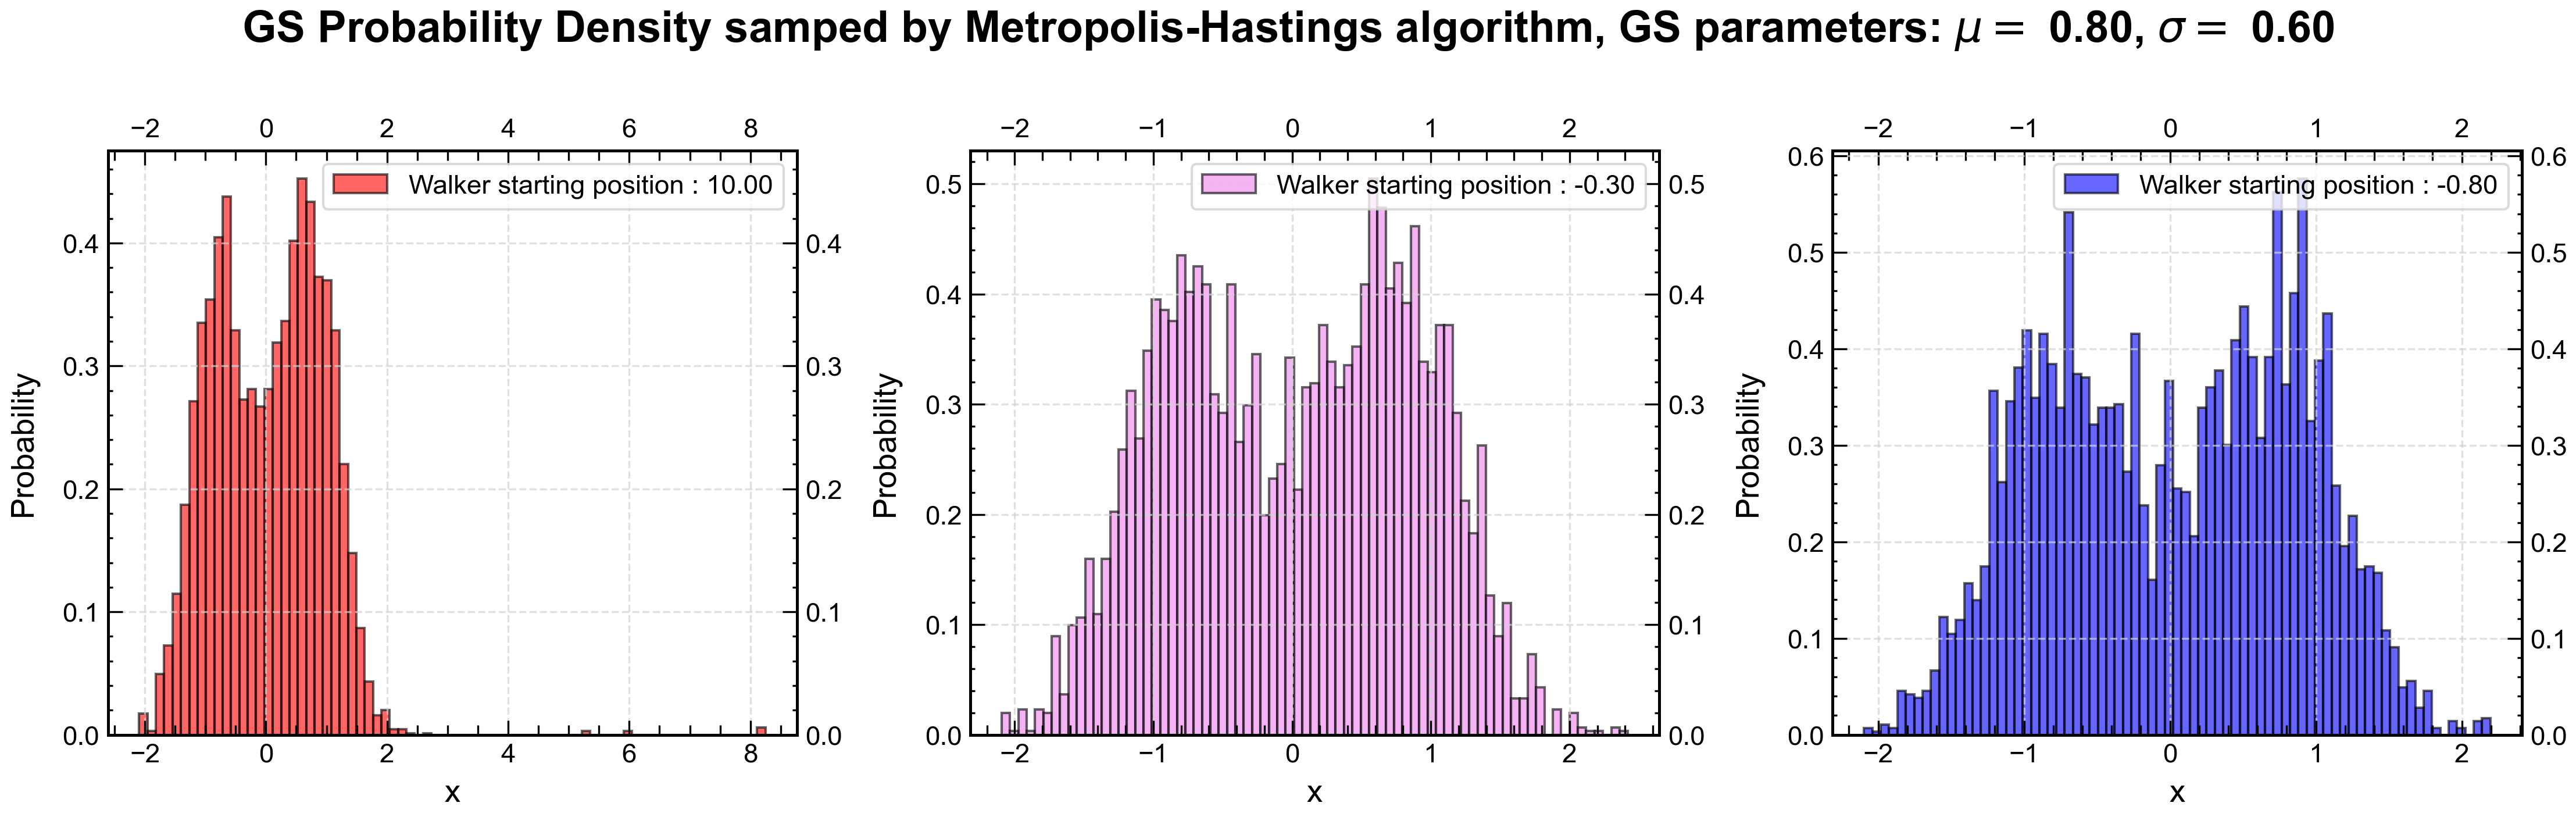

In [198]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

plt.suptitle(rf"GS Probability Density samped by Metropolis-Hastings algorithm, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].hist(pos1, bins=75, color='red', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].set_xlabel('x', labelpad=5)
axs[0].set_ylabel('Probability', labelpad=10)
axs[0].legend()
axs[1].hist(pos2, bins=75, color='violet', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].set_xlabel('x', labelpad=5)
axs[1].set_ylabel('Probability', labelpad=10)
axs[1].legend()
axs[2].hist(pos3, bins=75, color='blue', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start3:.2f}')
axs[2].set_xlabel('x', labelpad=5)
axs[2].set_ylabel('Probability', labelpad=10)
axs[2].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

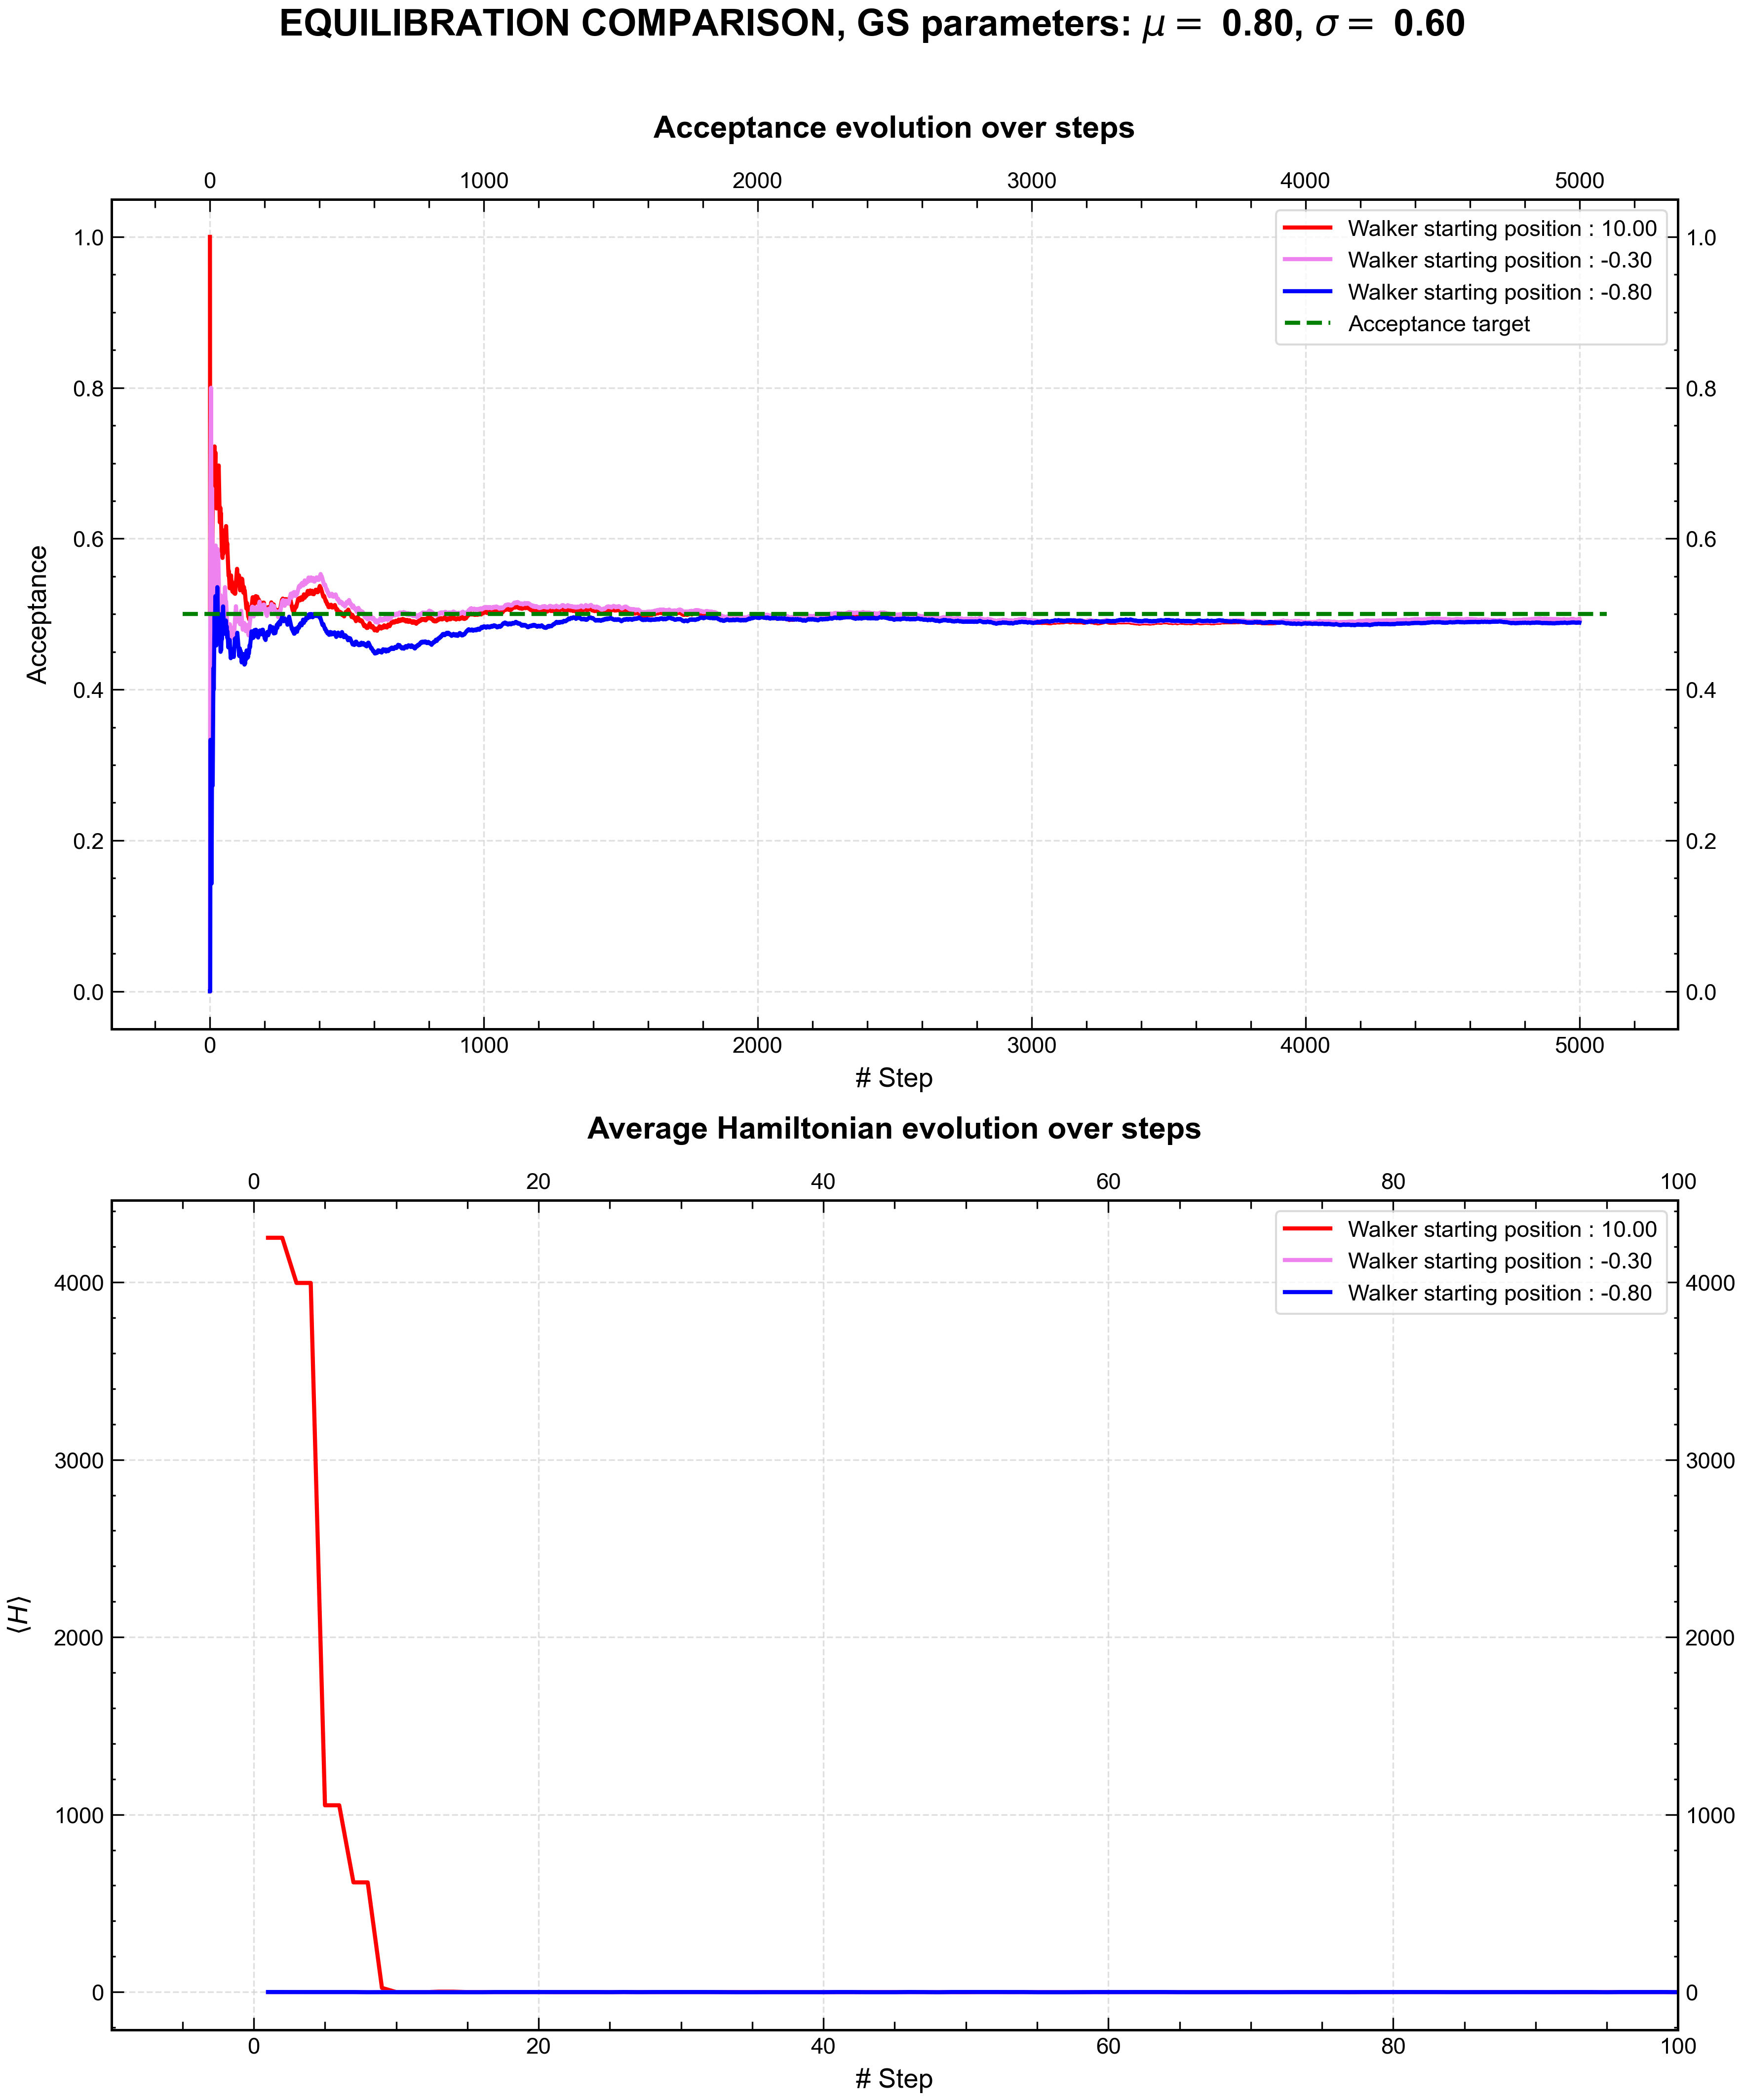

In [199]:
fig, axs = plt.subplots(2,1,figsize=(12,15))

plt.suptitle(rf"EQUILIBRATION COMPARISON, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].set_title("Acceptance evolution over steps", pad=30)
axs[0].plot(step, acceptance1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].plot(step, acceptance2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[0].plot(step, acceptance3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[0].set_xlabel('# Step', labelpad=5)
axs[0].set_ylabel('Acceptance', labelpad=10)
axs[0].hlines(0.5, xmin, xmax, color='green', linestyle='--', label='Acceptance target')
axs[0].legend()

axs[1].set_title("Average Hamiltonian evolution over steps", pad=30)
axs[1].plot(step, h1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[1].plot(step, h2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].plot(step, h3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[1].set_xlabel('# Step', labelpad=5)
axs[1].set_ylabel(r'$\langle H \rangle$', labelpad=10)
axs[1].set_xlim(-10, 100)
axs[1].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [208]:
acf_step = 10000
step, h = np.loadtxt("NSL_SIMULATOR/OUTPUT/hamiltonian.dat", usecols=(0,1), unpack=True)
step = step[:acf_step]
h = h[:acf_step]


In [209]:
def barlett_window(tau, tau_max = acf_step/10):
    if(tau > tau_max):
        return 0.0
    return 1 - (tau/tau_max)

def unbiased_acf(quantity, var):
    
    t_max = len(quantity)
    acorr = np.zeros(t_max)

    for t in range(t_max):

        delta_t = t_max - t
        norm_num = 1.0 / delta_t
        x = 0.0
        y = 0.0
        xy = 0.0

        for t_prime in range(delta_t):

            x += quantity[t_prime]
            y += quantity[t_prime + t]
            xy += quantity[t_prime] * quantity[t_prime + t]

        
        num = norm_num * xy - (norm_num * x) * (norm_num * y)
        acorr[t] = num / var

    return acorr

def integrated_ac_time(ac): 
    try:
        zero_crossing = np.where(ac < 0)[0][0]
    except IndexError:
        zero_crossing = len(ac)
    return 1 + 2 * np.sum(ac[1:zero_crossing])

In [210]:
var = np.var(h)

acf = unbiased_acf(h, var)
acf_barlett = acf * [barlett_window(t) for t in range(acf_step)]

NVE Correlation time from unbiased sample ACF : τ ≈ 3.19 steps
NVE Correlation time from unbiased sample ACF with Barlett window : τ ≈ 3.19 steps


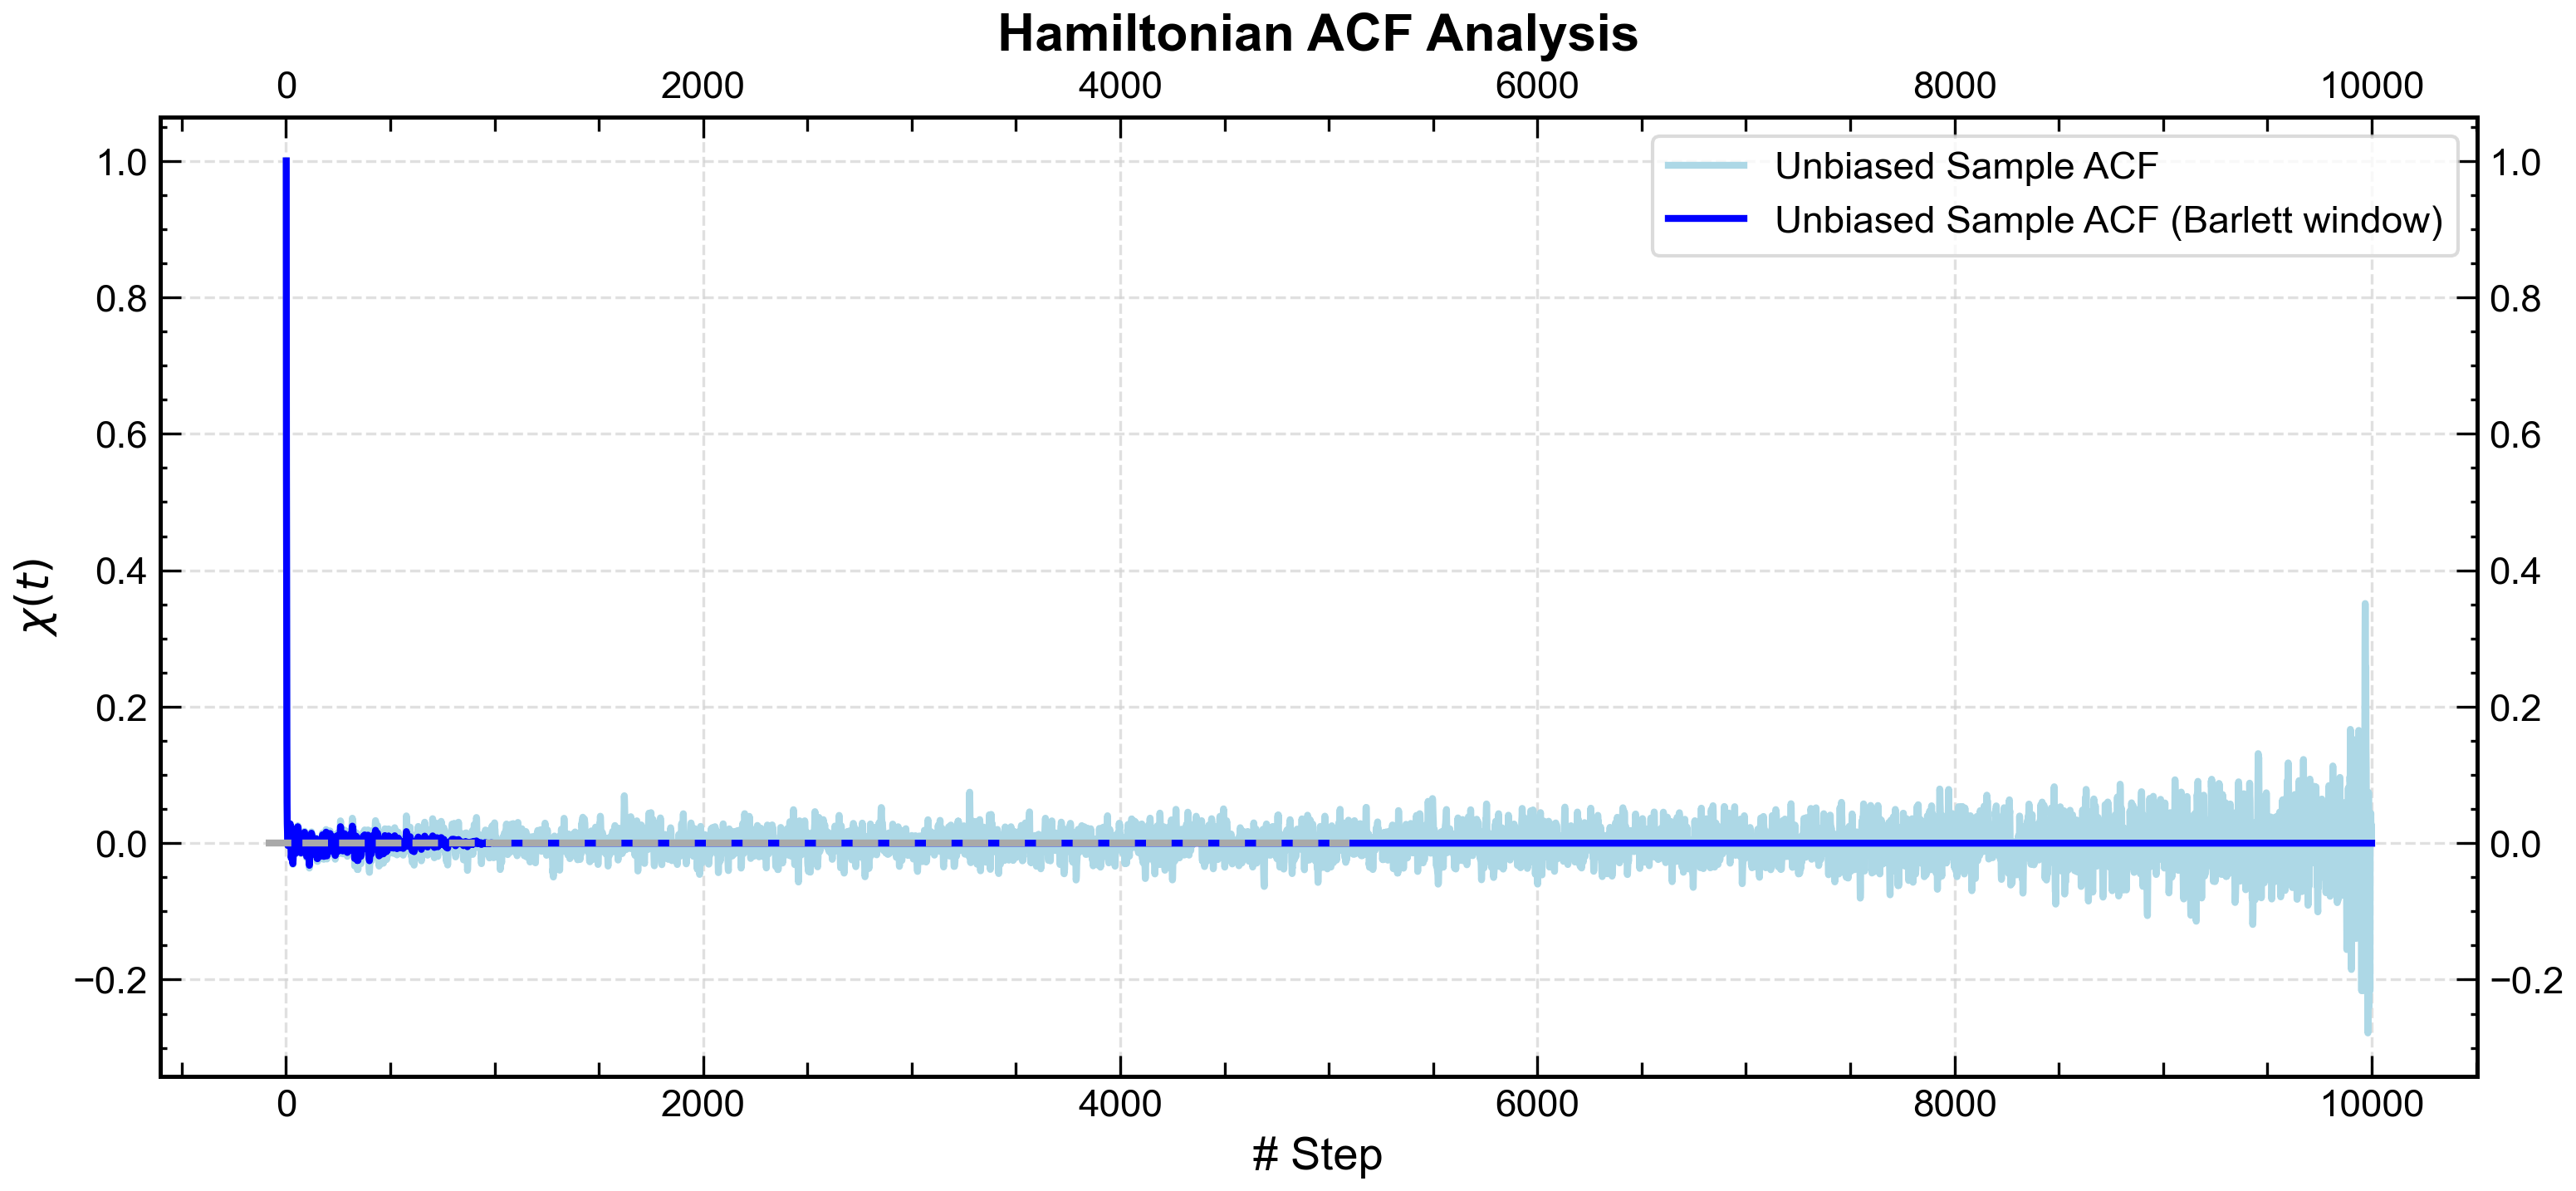

In [211]:
fig = plt.figure(figsize=(12, 5)) 

plt.title("Hamiltonian ACF Analysis")
plt.plot(step, acf, color="lightblue", label="Unbiased Sample ACF")
plt.plot(step, acf_barlett, color="blue", label="Unbiased Sample ACF (Barlett window)")
plt.xlabel("# Step")
plt.ylabel(r"$\chi(t)$")
plt.hlines(0, xmin, xmax, color="darkgrey", linestyle="--")
plt.legend()

ct = integrated_ac_time(acf)
ct_barlett = integrated_ac_time(acf_barlett)

print(f"NVE Correlation time from unbiased sample ACF : τ ≈ {ct:.2f} steps")
print(f"NVE Correlation time from unbiased sample ACF with Barlett window : τ ≈ {ct_barlett:.2f} steps")

plt.show()

In [212]:
def error(A_sum: float, A_sq_sum: float, i: int) -> float:
    
    # N_samp is the number of samples (blocks) calculated so far
    N_samp = i + 1 
    
    # If we have less than 2 samples, we cannot calculate the variance (ddof=1)
    if N_samp < 2:
        return 0.0
    
    # Calculate the cumulative mean of the squared block means (S2 / N_samp)
    A_sq_mean = A_sq_sum / N_samp
    # Calculate the cumulative mean of the block means (S1 / N_samp)
    A_mean = A_sum / N_samp

    # Calculate the variance numerator: E[A^2] - (E[A])^2
    num = A_sq_mean - A_mean**2

    # Calculate the Standard Deviation of the block means
    err = np.sqrt(num/(N_samp - 1))
    
    return err


def data_blocking(obs: np.ndarray, L: int) -> float:    # Calculates the final progressive error for a specific block length L
    
    M = len(obs)    # Total dataset size
    if L <= 0:
        return np.nan

    # Calculate N (number of blocks) using integer division (//)
    N = M // L
    
    if N < 2:
        # Cannot calculate variance with less than 2 blocks.
        return np.nan 
    
    # Determine the effective length of the data to be used (exact multiple of L)
    L_eff = N * L
    
    # Vectorized Calculation of Block Means (A_i)
    # 1. Truncation: obs[:L_eff] selects the data divisible by L
    # 2. Reshape: .reshape(N, L) creates a matrix where each row is a block 
    # 3. Mean: .mean(axis=1) calculates the mean for each row (single block mean A_i)
    block_means = obs[:L_eff].reshape(N, L).mean(axis=1)
    
    A_sum = 0.0      # Accumulator variable: Cumulative sum of block means (S1)
    A_sq_sum = 0.0   # Accumulator variable: Cumulative sum of squared block means (S2)
    
    last_error = 0.0 # Variable to store the error calculated on the last block

    # Loop over the N block means to calculate the progressive error
    for i in range(N):
        A_k = block_means[i]  # Current block mean (A_i)
        
        # Update the cumulative sum of means
        A_sum += A_k
        # Update the cumulative sum of squared means
        A_sq_sum += A_k * A_k
        
        # The final error (err[-1]) is calculated and saved only on the last iteration (i = N-1)
        if(i==N-1):
            last_error = error(A_sum, A_sq_sum, i)

    return last_error

In [213]:
h = np.loadtxt("NSL_SIMULATOR/OUTPUT/hamiltonian.dat", usecols=(1), unpack=True)
# Minimum block size
L_min = 1
# Maximum block size
L_max = 5000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err[i] = data_blocking(h, L)

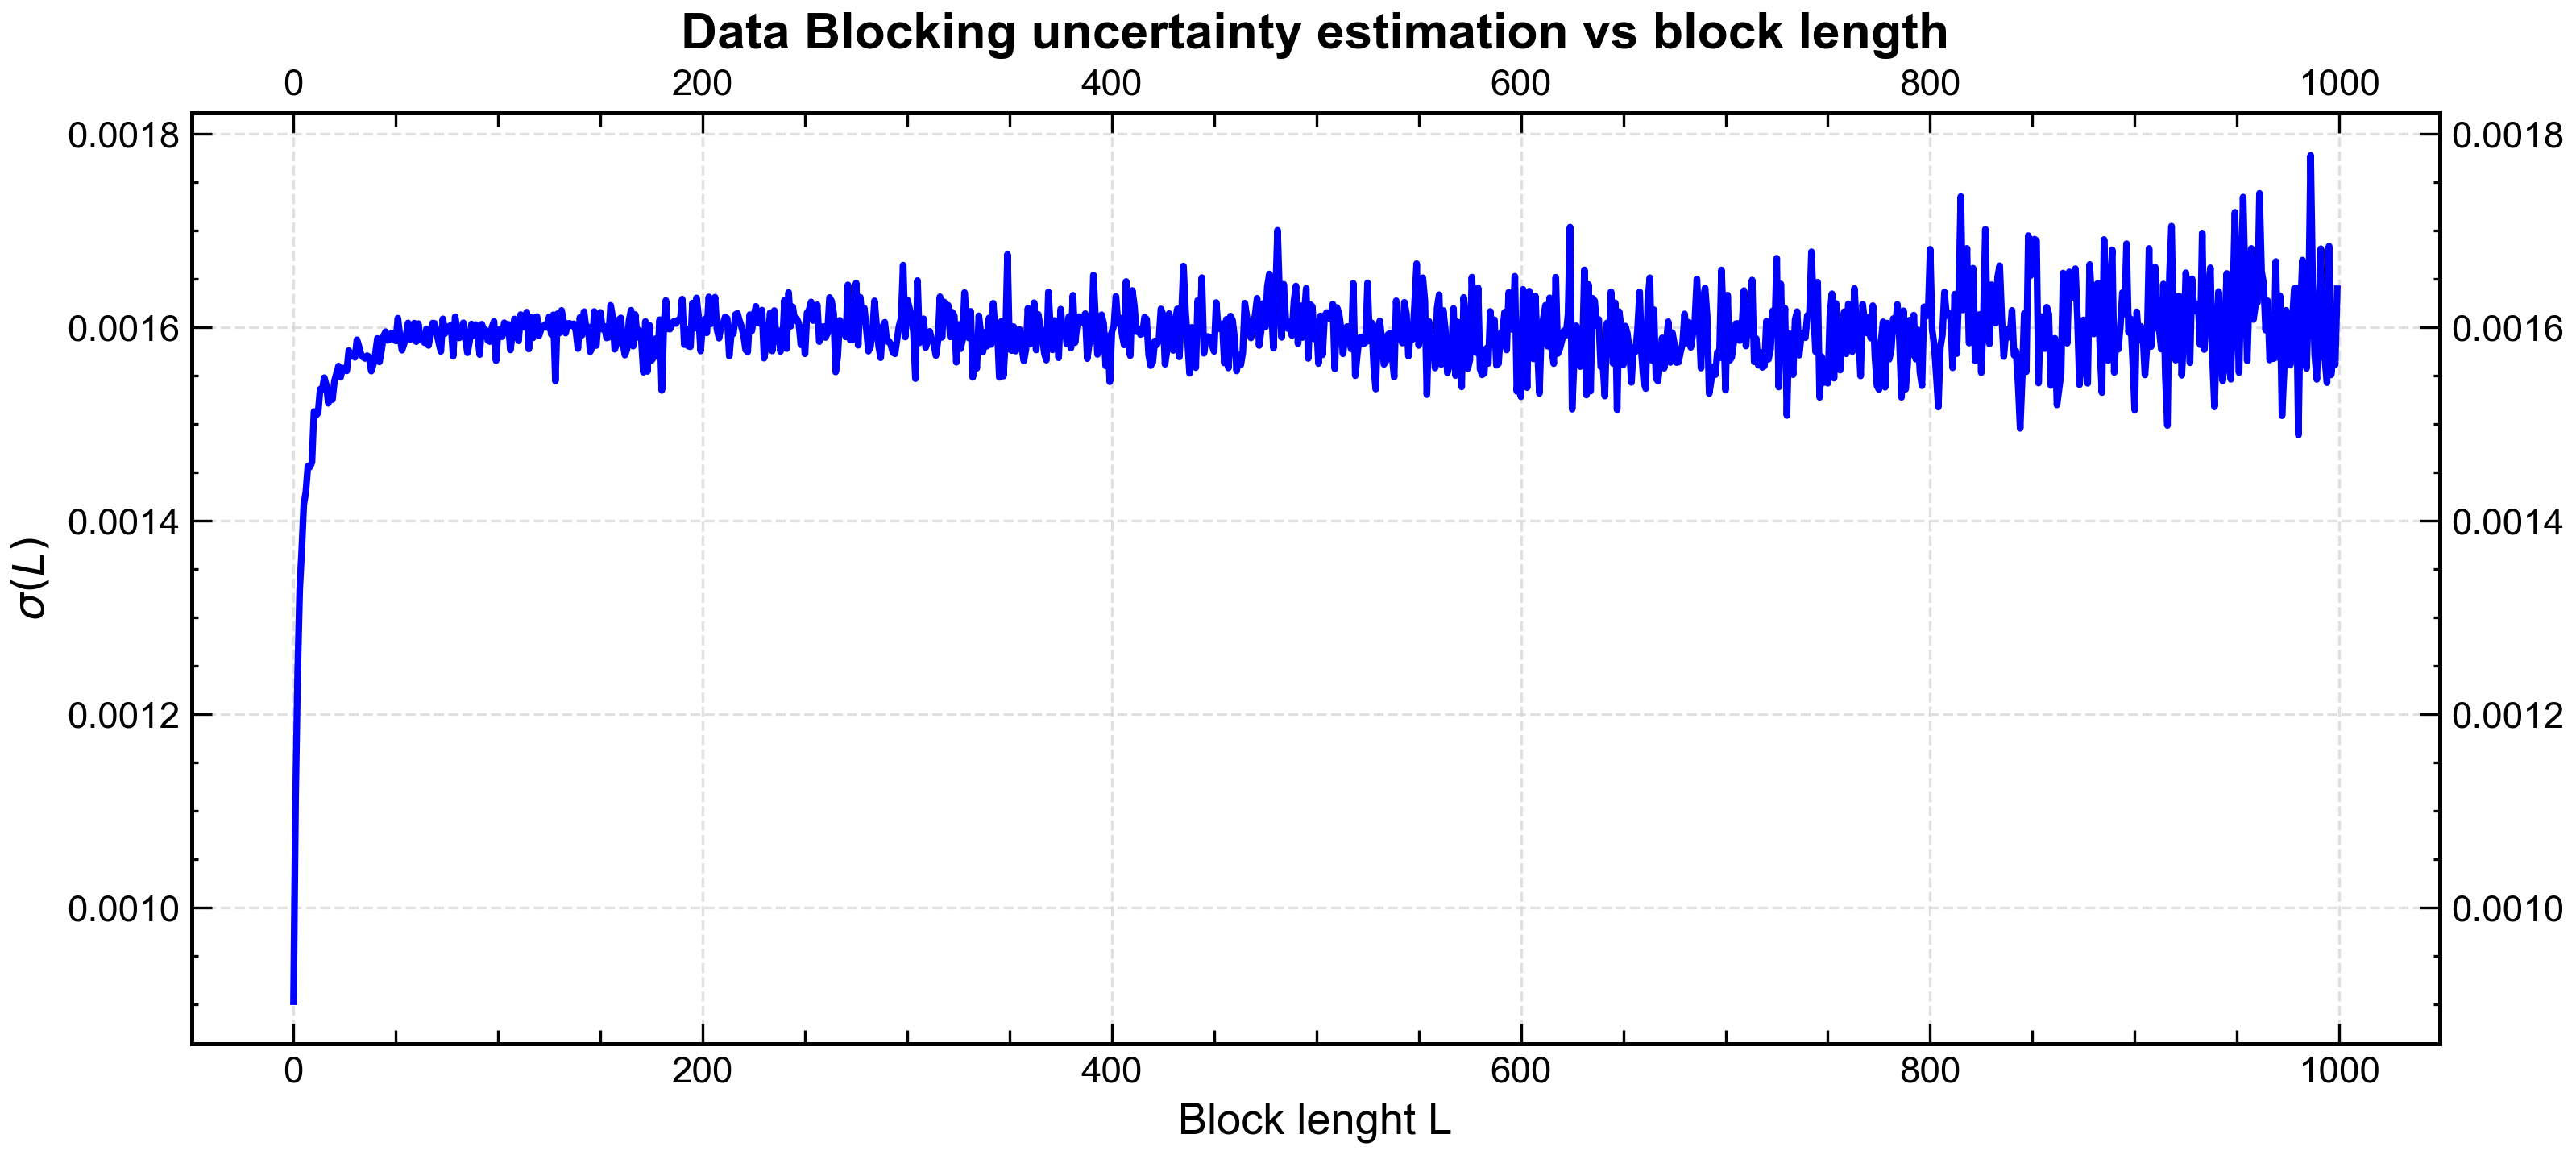

In [214]:
err = err[:1000]
x = np.arange(0, len(err))

fig = plt.figure(figsize=(12,5))

plt.title("Data Blocking uncertainty estimation vs block length")
plt.plot(x, err, color="blue")
plt.xlabel("Block lenght L")
# plt.xlim(-10,200)
# plt.xlim(-10,1000)
plt.ylabel(r"$\sigma (L)$")

plt.show()

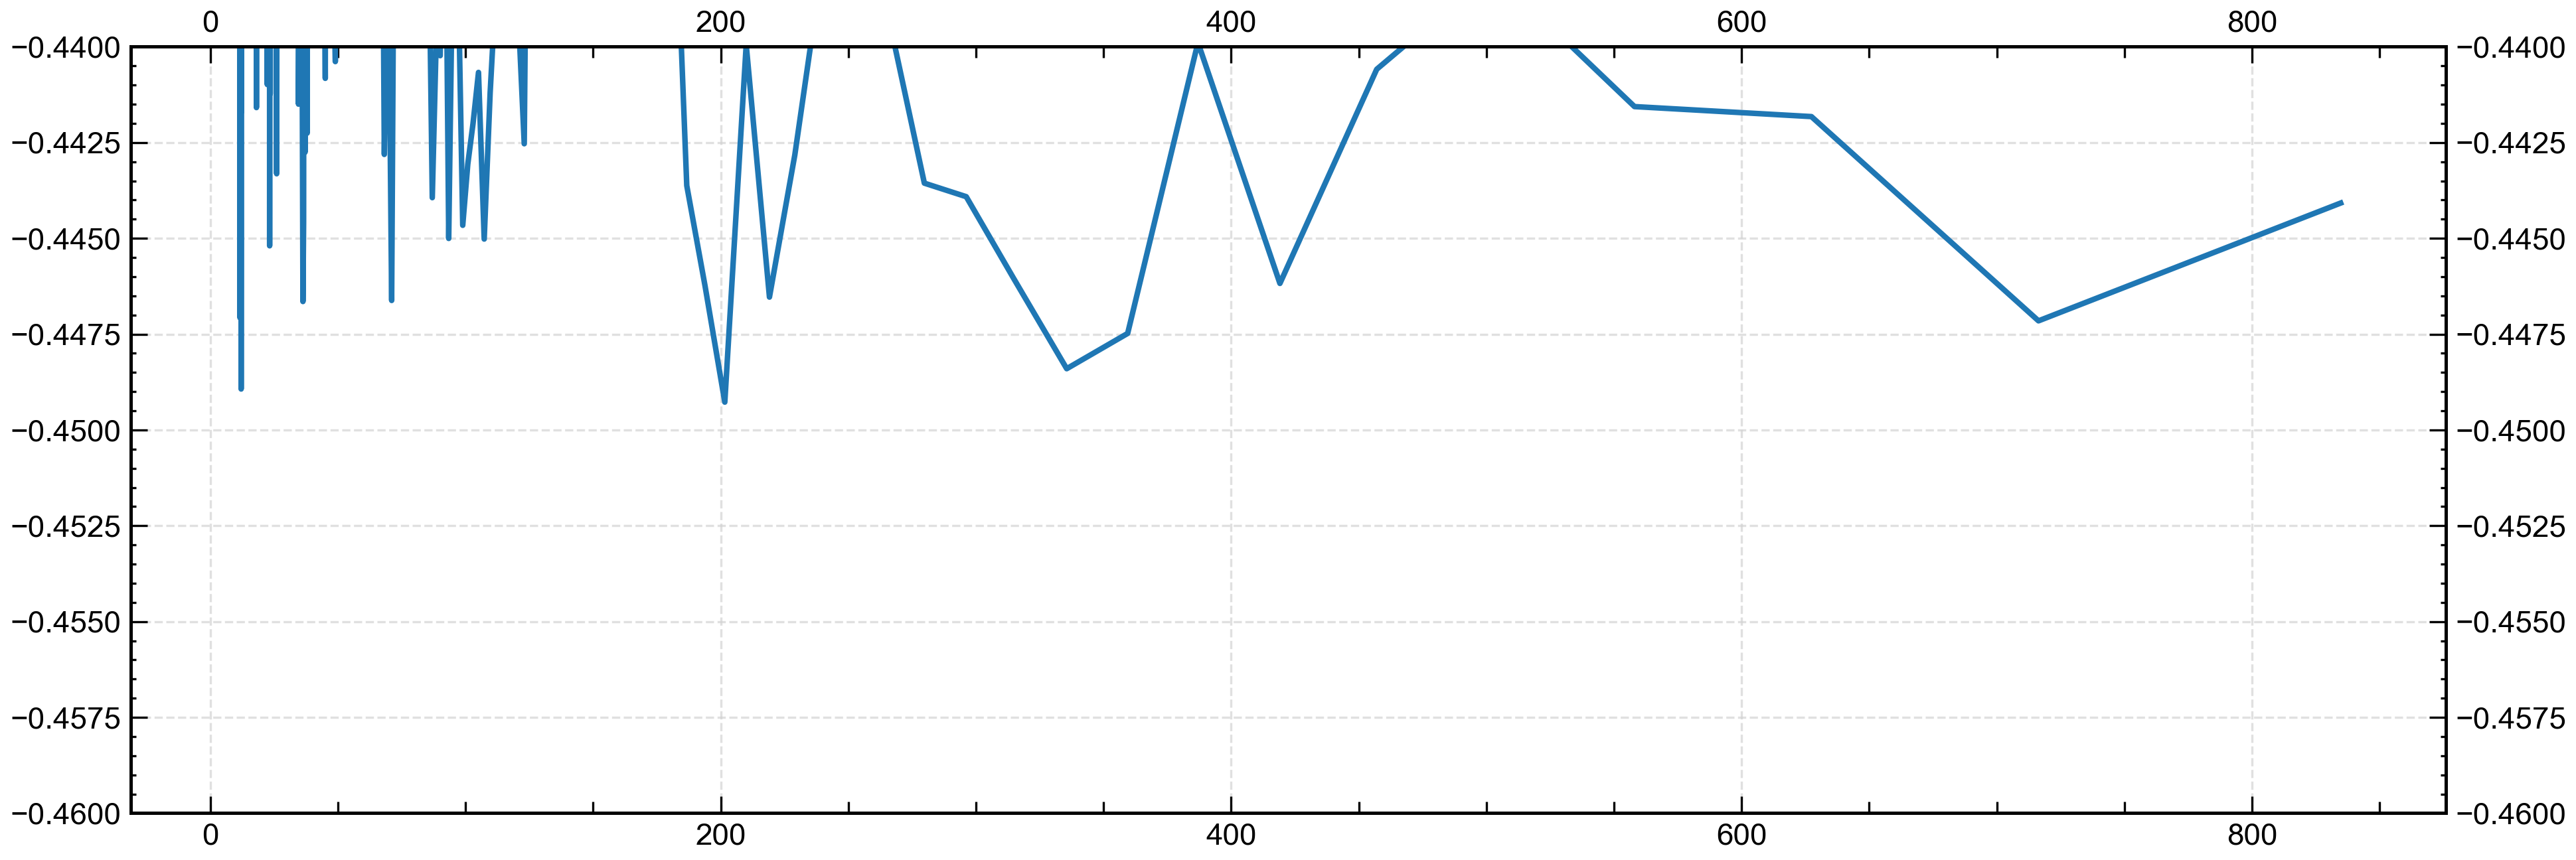

In [22]:
t, H = np.loadtxt("NSL_SIMULATOR/OUTPUT/data.dat", usecols=(0,3), unpack=True)
beta = 1/t
fig = plt.figure(figsize=(15,5))
plt.plot(beta, H)
#plt.xlim(8, 15)
plt.ylim(-0.46, -0.44)
plt.show()